1.MODEL EVALUATION AND PERFORMANCE METRICS

In [1]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Data
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df.iloc[:, :2]
df.columns = ["label", "message"]

# 2. Convert text labels ('ham'/'spam') to numbers (0/1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# 3. Clean Text Function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['cleaned_message'] = df['message'].apply(clean_text)

# 4. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_message'], 
    df['label_num'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label_num']
)

# 5. Convert Words into Numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 6. Train the Naive Bayes Model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 7. Evaluate Performance
y_pred = model.predict(X_test_tfidf)

print("--- MODEL ACCURACY ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("--- DETAILED REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

--- MODEL ACCURACY ---
Accuracy: 96.59%

--- DETAILED REPORT ---
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.75      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



2. MODEL COMPARISON AND VISUALIZATIONS

Logistic Regression Accuracy: 97.22%



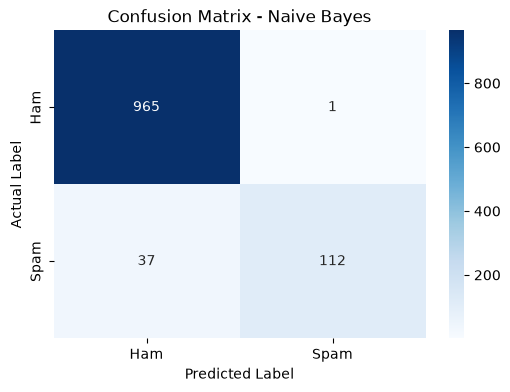

--- CUSTOM PREDICTIONS ---
Test 1: Result: SPAM (84.45% confidence)
Test 2: Result: HAM (Legitimate) (99.63% confidence)


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# --- 1. Train a second model (Logistic Regression) ---
log_model = LogisticRegression()
log_model.fit(X_train_tfidf, y_train)

y_pred_log = log_model.predict(X_test_tfidf)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log) * 100:.2f}%\n")

# --- 2. Plot Confusion Matrix for Naive Bayes ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

# --- 3. Interactive Prediction Function ---
def predict_message(custom_text):
    cleaned = clean_text(custom_text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    
    label = "SPAM" if prediction == 1 else "HAM (Legitimate)"
    confidence = max(probability) * 100
    return f"Result: {label} ({confidence:.2f}% confidence)"

# --- Test custom messages ---
print("--- CUSTOM PREDICTIONS ---")
print("Test 1:", predict_message("Congratulations! You won a $1,000 Walmart gift card. Click here to claim!"))
print("Test 2:", predict_message("Hey, are we still meeting for lunch today at 1 PM?"))

3. MODEL SERIALIZATION AND PERSISTANCE

In [4]:
import joblib

# 1. Save the trained Naive Bayes model and TF-IDF vectorizer to disk
joblib.dump(model, 'spam_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model and Vectorizer successfully saved as '.pkl' files!")

Model and Vectorizer successfully saved as '.pkl' files!


4. INTERACTIVE USER INTERFACE


In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Create interactive UI widgets inside the notebook
text_input = widgets.Textarea(
    placeholder='Type or paste an email/SMS message here...',
    description='Message:',
    layout=widgets.Layout(width='80%', height='100px')
)

button = widgets.Button(
    description='Check Message',
    button_style='primary'
)

output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        msg = text_input.value.strip()
        if not msg:
            print("Please enter a message first.")
            return
            
        cleaned = clean_text(msg)
        vectorized = tfidf.transform([cleaned])
        prediction = model.predict(vectorized)[0]
        confidence = max(model.predict_proba(vectorized)[0]) * 100
        
        if prediction == 1:
            print(f"🚨 Result: SPAM ({confidence:.2f}% confidence)")
        else:
            print(f"✅ Result: HAM / Legitimate ({confidence:.2f}% confidence)")

button.on_click(on_button_clicked)

# Display the UI elements inside your notebook
display(text_input, button, output)

Textarea(value='', description='Message:', layout=Layout(height='100px', width='80%'), placeholder='Type or pa…

Button(button_style='primary', description='Check Message', style=ButtonStyle())

Output()

5. FEATURE IMPORTANCE & TOP PREDICTIVE WORDS

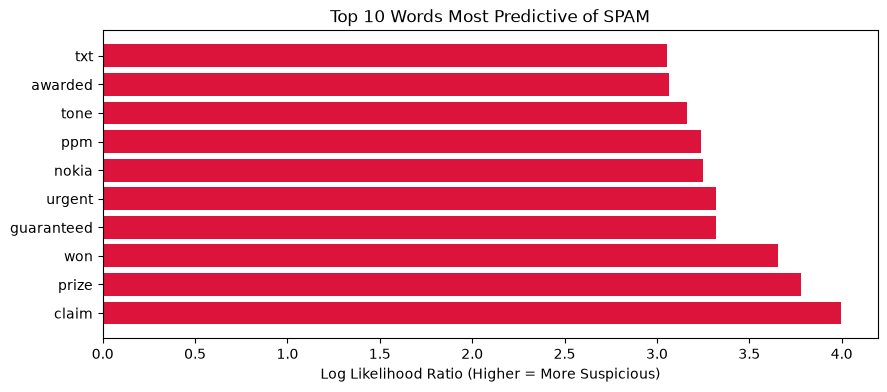

--- DETAILED PERFORMANCE METRICS ---
Precision (How many flagged emails are actually spam): 99.12%
Recall (How many actual spam emails were caught):      75.17%
F1-Score (Balanced measure of precision and recall):   85.50%


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

# --- 1. Top Spam & Ham Words (Feature Importance) ---
feature_names = np.array(tfidf.get_feature_names_out())
# Get log probability feature weights from Naive Bayes
spam_probabilities = model.feature_log_prob_[1]
ham_probabilities = model.feature_log_prob_[0]

# Calculate log likelihood ratio (higher = strongly associated with spam)
log_ratio = spam_probabilities - ham_probabilities

# Top 10 Spam Words
top_spam_indices = np.argsort(log_ratio)[-10:]
top_spam_words = feature_names[top_spam_indices]
top_spam_scores = log_ratio[top_spam_indices]

# Top 10 Ham Words
top_ham_indices = np.argsort(log_ratio)[:10]
top_ham_words = feature_names[top_ham_indices]
top_ham_scores = log_ratio[top_ham_indices]

# --- 2. Plot Top Spam Words ---
plt.figure(figsize=(10, 4))
plt.barh(top_spam_words, top_spam_scores, color='crimson')
plt.title("Top 10 Words Most Predictive of SPAM")
plt.xlabel("Log Likelihood Ratio (Higher = More Suspicious)")
plt.gca().invert_yaxis()
plt.show()

# --- 3. Compute Precision, Recall, and F1-Score ---
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- DETAILED PERFORMANCE METRICS ---")
print(f"Precision (How many flagged emails are actually spam): {precision * 100:.2f}%")
print(f"Recall (How many actual spam emails were caught):      {recall * 100:.2f}%")
print(f"F1-Score (Balanced measure of precision and recall):   {f1 * 100:.2f}%")

6. BATCH PREDICTION AND REPORT EXPORT


In [8]:
import pandas as pd

# 1. Define a batch of new test messages
sample_messages = [
    "URGENT! You have won a $1,000 Walmart gift card. Click http://bit.ly/claim now!",
    "Hey, are we still meeting for lunch today at 1 PM?",
    "CLAIM YOUR FREE PRIZE NOW! Call 08000930705 to claim your £1000 cash.",
    "Can you please send me the project report files before the meeting?",
    "Congratulations! You've been selected for a free trial. Reply YES to accept."
]

# 2. Preprocess and transform sample batch
cleaned_samples = [clean_text(msg) for msg in sample_messages]
sample_vectors = tfidf.transform(cleaned_samples)

# 3. Predict labels and probability scores
predictions = model.predict(sample_vectors)
probabilities = model.predict_proba(sample_vectors)

# 4. Construct results DataFrame
results_df = pd.DataFrame({
    'Message': sample_messages,
    'Predicted_Label': ['SPAM' if pred == 1 else 'HAM' for pred in predictions],
    'Confidence_Score (%)': [round(max(prob) * 100, 2) for prob in probabilities]
})

# 5. Export to CSV file
results_df.to_csv('spam_predictions_report.csv', index=False)

print("--- BATCH PREDICTION RESULTS ---")
display(results_df)
print("\nResults successfully saved to 'spam_predictions_report.csv'!")

--- BATCH PREDICTION RESULTS ---


,Message,Predicted_Label,Confidence_Score (%)
0,"URGENT! You have won a $1,000 Walmart gift car...",SPAM,80.89
1,"Hey, are we still meeting for lunch today at 1...",HAM,99.63
2,CLAIM YOUR FREE PRIZE NOW! Call 08000930705 to...,SPAM,97.07
3,Can you please send me the project report file...,HAM,97.99
4,Congratulations! You've been selected for a fr...,SPAM,67.59



Results successfully saved to 'spam_predictions_report.csv'!


7. PIPELINE ARTIFACTS & PROJECT SUMMARY

In [9]:
import joblib
import os

# --- 1. Persist Model and Vectorizer Assets ---
model_filename = 'spam_model_nb.pkl'
vectorizer_filename = 'tfidf_vectorizer.pkl'

joblib.dump(model, model_filename)
joblib.dump(tfidf, vectorizer_filename)

model_size = os.path.getsize(model_filename) / 1024
vectorizer_size = os.path.getsize(vectorizer_filename) / 1024

print("--- SAVED ASSETS SUMMARY ---")
print(f"✓ Model saved as: '{model_filename}' ({model_size:.2f} KB)")
print(f"✓ Vectorizer saved as: '{vectorizer_filename}' ({vectorizer_size:.2f} KB)")


# --- 2. Sanity Check: Load and Test Pipeline from Disk ---
print("\n--- SANITY CHECK (RELOADING FROM DISK) ---")
loaded_model = joblib.load(model_filename)
loaded_tfidf = joblib.load(vectorizer_filename)

test_msg = "URGENT! Your mobile number has won £2000 bonus credits. Reply CLAIM now."
cleaned_test = clean_text(test_msg)
vec_test = loaded_tfidf.transform([cleaned_test])
pred = loaded_model.predict(vec_test)[0]
prob = max(loaded_model.predict_proba(vec_test)[0]) * 100

res_label = "SPAM" if pred == 1 else "HAM"
print(f"Test Query: \"{test_msg}\"")
print(f"Pipeline Result: {res_label} ({prob:.2f}% confidence)")


# --- 3. Final Notebook Execution Summary ---
print("\n" + "="*50)
print("       SPAM DETECTION PROJECT COMPLETE        ")
print("="*50)
print("1. Data Preprocessing & Cleaning Complete")
print("2. TF-IDF Feature Extraction Applied")
print("3. Naive Bayes & Logistic Regression Trained")
print("4. Evaluation Metrics & Feature Importance Plotted")
print("5. In-Notebook UI Widgets Configured")
print("6. Batch Report Exported to 'spam_predictions_report.csv'")
print("7. Trained Model Artifacts Serialized to Disk")
print("="*50)

--- SAVED ASSETS SUMMARY ---
✓ Model saved as: 'spam_model_nb.pkl' (94.52 KB)
✓ Vectorizer saved as: 'tfidf_vectorizer.pkl' (105.02 KB)

--- SANITY CHECK (RELOADING FROM DISK) ---
Test Query: "URGENT! Your mobile number has won £2000 bonus credits. Reply CLAIM now."
Pipeline Result: SPAM (99.09% confidence)

       SPAM DETECTION PROJECT COMPLETE        
1. Data Preprocessing & Cleaning Complete
2. TF-IDF Feature Extraction Applied
3. Naive Bayes & Logistic Regression Trained
4. Evaluation Metrics & Feature Importance Plotted
5. In-Notebook UI Widgets Configured
6. Batch Report Exported to 'spam_predictions_report.csv'
7. Trained Model Artifacts Serialized to Disk


8. ADVANCED FEATURE ENGINEERING: N-GRAM ANALYSIS

In [10]:
# Try bi-grams for better context capture
tfidf_ngram = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_ngram = tfidf_ngram.fit_transform(X_train)
X_test_ngram = tfidf_ngram.transform(X_test)

model_ngram = MultinomialNB()
model_ngram.fit(X_train_ngram, y_train)

print(f"N-Gram Model Accuracy: {accuracy_score(y_test, model_ngram.predict(X_test_ngram)) * 100:.2f}%")

N-Gram Model Accuracy: 96.95%


9. TEXT PREPROCESSING WITH NLTK

In [11]:
# Try bi-grams for better context capture
tfidf_ngram = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_ngram = tfidf_ngram.fit_transform(X_train)
X_test_ngram = tfidf_ngram.transform(X_test)

model_ngram = MultinomialNB()
model_ngram.fit(X_train_ngram, y_train)

print(f"N-Gram Model Accuracy: {accuracy_score(y_test, model_ngram.predict(X_test_ngram)) * 100:.2f}%")

N-Gram Model Accuracy: 96.95%


10. DATASET CLASS DISTRIBUTION ANALYSIS

In [12]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# --- Class Distribution Check ---
print("--- CLASS COUNTS ---")
print(df['label'].value_counts())
print("\n--- CLASS PERCENTAGES ---")
print(df['label'].value_counts(normalize=True) * 100)

# --- Preprocessing with Stopword Removal ---
def clean_text_with_stopwords(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    # Remove common English stopwords
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df['cleaned_message'] = df['message'].apply(clean_text_with_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\NG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- CLASS COUNTS ---
label
ham     4825
spam     747
Name: count, dtype: int64

--- CLASS PERCENTAGES ---
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


11. EXPLORATORY DATA ANALYSIS: WORD CLOUDS

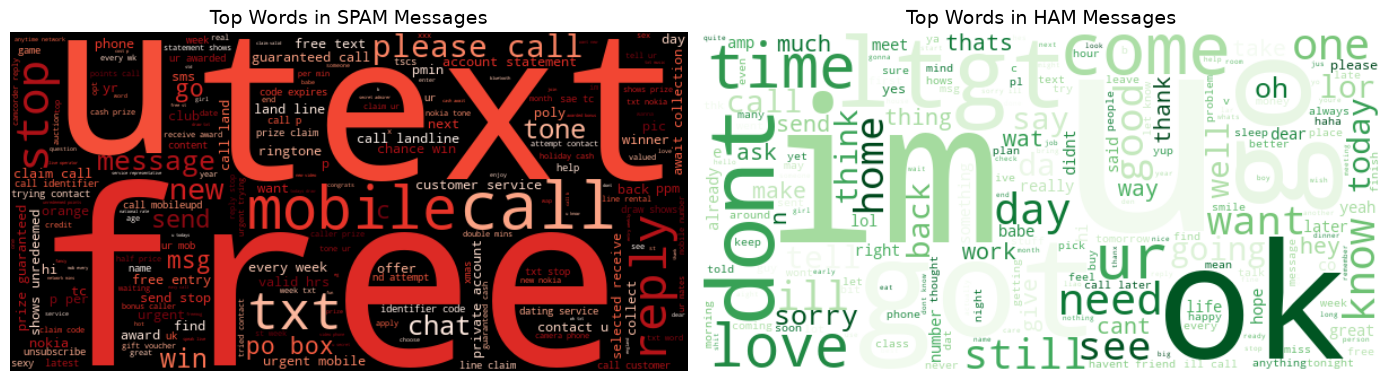

In [14]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_text = " ".join(df[df['label_num'] == 1]['cleaned_message'])
ham_text = " ".join(df[df['label_num'] == 0]['cleaned_message'])

wc_spam = WordCloud(width=600, height=300, background_color='black', colormap='Reds').generate(spam_text)
wc_ham = WordCloud(width=600, height=300, background_color='white', colormap='Greens').generate(ham_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].set_title('Top Words in SPAM Messages', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].set_title('Top Words in HAM Messages', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

12. MODEL VALIDATION: K-FOLDS CROSS VALIDATION

In [14]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='accuracy')

print("--- 5-FOLD CROSS-VALIDATION RESULTS ---")
print(f"Fold Accuracies: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}% (± {cv_scores.std() * 100:.2f}%)")

--- 5-FOLD CROSS-VALIDATION RESULTS ---
Fold Accuracies: [0.97421525 0.96188341 0.97867565 0.95735129 0.96969697]
Mean CV Accuracy: 96.84% (± 0.78%)


13. PERFORMANCE EVALUATION: ROC CURVE & AUC SCORE

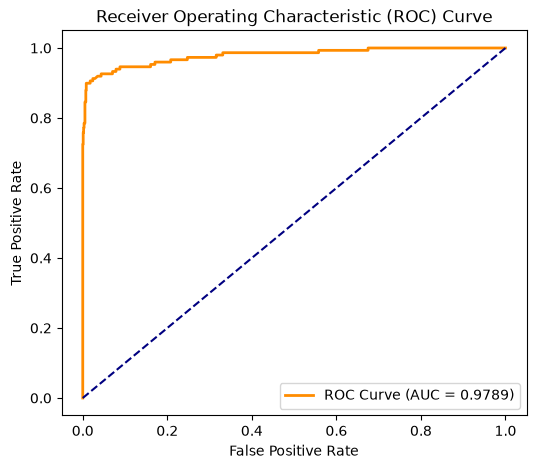

ROC-AUC Score: 0.9789


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability predictions for spam
y_probs = model.predict_proba(X_test_tfidf)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

14. HYPERPARAMETER TUNING: GRIDSEARCHCV

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0]}
grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_tfidf, y_train)

print("--- HYPERPARAMETER TUNING ---")
print("Best Alpha Parameter:", grid_search.best_params_)
print(f"Best CV F1-Score: {grid_search.best_score_ * 100:.2f}%")

--- HYPERPARAMETER TUNING ---
Best Alpha Parameter: {'alpha': 0.1}
Best CV F1-Score: 94.15%


15. ERROR ANALYSIS: FALSE POSITIVES & FALSE NEGATIVES

In [18]:
# Create a DataFrame of test predictions to find misclassifications
test_analysis = pd.DataFrame({
    'Message': X_test,
    'Actual': y_test,
    'Predicted': y_pred
})

false_positives = test_analysis[(test_analysis['Actual'] == 0) & (test_analysis['Predicted'] == 1)]
false_negatives = test_analysis[(test_analysis['Actual'] == 1) & (test_analysis['Predicted'] == 0)]

print(f"Total False Positives (Ham flagged as Spam): {len(false_positives)}")
print(f"Total False Negatives (Spam missed by filter): {len(false_negatives)}\n")

print("--- SAMPLE FALSE POSITIVES ---")
display(false_positives.head(3))

print("\n--- SAMPLE FALSE NEGATIVES ---")
display(false_negatives.head(3))

Total False Positives (Ham flagged as Spam): 1
Total False Negatives (Spam missed by filter): 37

--- SAMPLE FALSE POSITIVES ---


,Message,Actual,Predicted
4860,nokia phone is lovly,0,1



--- SAMPLE FALSE NEGATIVES ---


,Message,Actual,Predicted
3057,you are now unsubscribed all services get tons...,1,0
5,freemsg hey there darling its been weeks now ...,1,0
1021,guess what somebody you know secretly fancies ...,1,0
